In [28]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
import json
from dataclasses import dataclass
import os

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms 
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

from PIL import Image


def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print("torchvision:", torchvision.__version__)
print(f"device: {device}")
    


torch: 2.10.0+cpu
cuda: None
torchvision: 0.25.0+cpu
device: cpu


In [13]:
class MyCNN(nn.Module):
    def __init__(self, num_classes: int=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),    #96
            nn.ReLU(),
            nn.MaxPool2d(2),                               #48

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  #48
            nn.ReLU(),
            nn.MaxPool2d(2),                               #24

            nn.Conv2d(64, 128, kernel_size=3, padding=1), #24
            nn.ReLU(),
            nn.MaxPool2d(2),                               #12

            nn.Conv2d(128, 256, kernel_size=3, padding=1), #12
            nn.ReLU(),
            nn.MaxPool2d(2),                               #6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.2),
            nn.ReLU(),
            nn.Linear(512, 64),
            nn.BatchNorm1d(64),
            nn.Dropout(p=0.2),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.features(x))
    
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True, early_stopping: EarlyStopping=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {val_loss:.4f}, acc {val_acc:.3f}"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(val_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

        if early_stopping is not None:
            if early_stopping.step(val_acc, model):
                if verbose:
                    print(f"Остановка на эпохе {epoch};\nСворачиваем всю порнографиб, лучший результат: val_acc={early_stopping.best_score}")
                early_stopping.restore_best(model)
                break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

def build_resnet18(weights=get_resnet18_weights(), num_classes: int = 10) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

gen = torch.Generator().manual_seed(42)

train_full = torchvision.datasets.STL10(root="./data1", split="train", download=True, transform=transform)
test_ds = torchvision.datasets.STL10(root="./data1", split="test", download=True, transform=transform)

train_ds, val_ds = random_split(train_full, [int(i) for i in (len(train_full) * 0.8, len(train_full) * 0.2)], gen)

class_names = train_full.classes
print("train_ds:", len(train_ds))
print("val_ds:", len(val_ds))
print("test_ds:", len(test_ds))
print("Classes:", class_names, len(class_names))

train_ds: 4000
val_ds: 1000
test_ds: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck'] 10


In [15]:
train_loader = DataLoader(dataset=train_ds, batch_size=64, shuffle=True, num_workers=4, pin_memory="False")
val_loader = DataLoader(dataset=val_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory="False")
test_loader = DataLoader(dataset=test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory="False")

x_batch, y_batch = next(iter(train_loader))
print(f"x_batch: {x_batch.shape}, {x_batch.dtype}")
print(f"y_batch: {y_batch.shape}, {y_batch.dtype}")


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x_batch: torch.Size([64, 3, 96, 96]), torch.float32
y_batch: torch.Size([64]), torch.int64


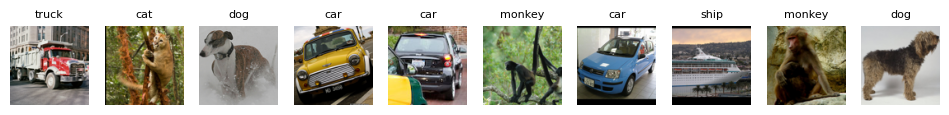

In [16]:
def denorm(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor((0.485, 0.456, 0.406)).view(3, 1, 1)
    std = torch.tensor((0.229, 0.224, 0.225)).view(3, 1, 1)
    return x * std + mean


def show_batch(loader ,num: int):
    x_batch, y_batch = next(iter(loader))[:num]
    plt.figure(figsize=(12, 2))
    for i in range(num):
        plt.subplot(1, num, i + 1)
        img = denorm(x_batch[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(train_full.classes[y_batch[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_batch(train_loader, 10)



In [17]:
cnn = MyCNN().to(device)
print(cnn)

with torch.no_grad():
    x0 = torch.randn(64, 3, 96, 96).to(device)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)


MyCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=Fals

In [18]:
criterion = nn.CrossEntropyLoss()

C1 = MyCNN().to(device)
optimizer = optim.Adam(C1.parameters(), lr=1e-3, weight_decay=0.0)

histC1 = fit(C1, train_loader, val_loader, optimizer, criterion, 20, early_stopping=EarlyStopping())
plot_history(histC1, "model C1")

Epoch 01/20 | train loss 1.8104, acc 0.348 | val loss 1.8652, acc 0.323
Epoch 02/20 | train loss 1.4240, acc 0.494 | val loss 1.4379, acc 0.482
Epoch 03/20 | train loss 1.2100, acc 0.577 | val loss 1.4688, acc 0.470
Epoch 04/20 | train loss 1.0438, acc 0.637 | val loss 1.4470, acc 0.490
Epoch 05/20 | train loss 0.8799, acc 0.696 | val loss 1.2712, acc 0.554
Epoch 06/20 | train loss 0.6879, acc 0.776 | val loss 1.1670, acc 0.582
Epoch 07/20 | train loss 0.5265, acc 0.840 | val loss 1.4746, acc 0.533


KeyboardInterrupt: 

In [ ]:
runs = pd.read_csv("./artifacts/runs.csv")

new_row = {
    "experiment_id": "С1",
    "task": "classification",
    "dataset": "STL10",
    "seed": 42,
    "model_summary": {"features": {"Conv2d": (3, 32, 64, 128, 256),
                                   "activation": "ReLU",
                                   "MaxPool2d": 2},
                    "classifier": {"hiden size": (512, 64), 
                                   "activation": "ReLU", 
                                   "dropout": 0.2, 
                                   "batchnorm": True}
                      },
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": 20,
    "best_val_accuracy": max(histC1["val_acc"]),
    "test_accuracy": evaluate(C1, test_loader, nn.CrossEntropyLoss())[1],
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "note": None
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
train_tf = transforms.Compose([
    transforms.Resize(96 + 14),
    transforms.RandomResizedCrop(96, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

eval_tf = transforms.Compose([
    transforms.Resize(96 + 14),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

ds_train_aug  = torchvision.datasets.STL10(root="./data1", split="train", download=False, transform=train_tf)
ds_train_eval = torchvision.datasets.STL10(root="./data1", split="train", download=False, transform=eval_tf)
ds_test = torchvision.datasets.STL10(root="./data1", split="test", download=False, transform=eval_tf)
class_names = ds_train_aug.classes
print("Train full:", len(ds_train_aug))
print("Test:", len(ds_test))


def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = 64,
    val_ratio: float = 0.2,
    seed: int = 42,
    fast_mode: bool = False,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader2, val_loader2, test_loader2 = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test)

x, y = next(iter(train_loader2))
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

Train full: 5000
Test: 8000


d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x: torch.Size([64, 3, 96, 96]) torch.float32
y: torch.Size([64]) torch.int64


Epoch 01/20 | train loss 1.8491, acc 0.331 | val loss 1.7207, acc 0.354
Epoch 02/20 | train loss 1.5745, acc 0.432 | val loss 1.6805, acc 0.400
Epoch 03/20 | train loss 1.4407, acc 0.474 | val loss 1.4768, acc 0.449
Epoch 04/20 | train loss 1.3299, acc 0.511 | val loss 1.3749, acc 0.473
Epoch 05/20 | train loss 1.2200, acc 0.562 | val loss 1.5024, acc 0.459
Epoch 06/20 | train loss 1.1517, acc 0.580 | val loss 1.4267, acc 0.479
Epoch 07/20 | train loss 1.0592, acc 0.623 | val loss 1.2203, acc 0.561
Epoch 08/20 | train loss 0.9962, acc 0.645 | val loss 1.5804, acc 0.474
Epoch 09/20 | train loss 0.9678, acc 0.656 | val loss 1.1996, acc 0.579
Epoch 10/20 | train loss 0.8980, acc 0.676 | val loss 1.2900, acc 0.548
Epoch 11/20 | train loss 0.8444, acc 0.703 | val loss 1.1371, acc 0.597
Epoch 12/20 | train loss 0.8106, acc 0.716 | val loss 1.0404, acc 0.633
Epoch 13/20 | train loss 0.7772, acc 0.722 | val loss 1.0825, acc 0.620
Epoch 14/20 | train loss 0.7099, acc 0.751 | val loss 1.1879, ac

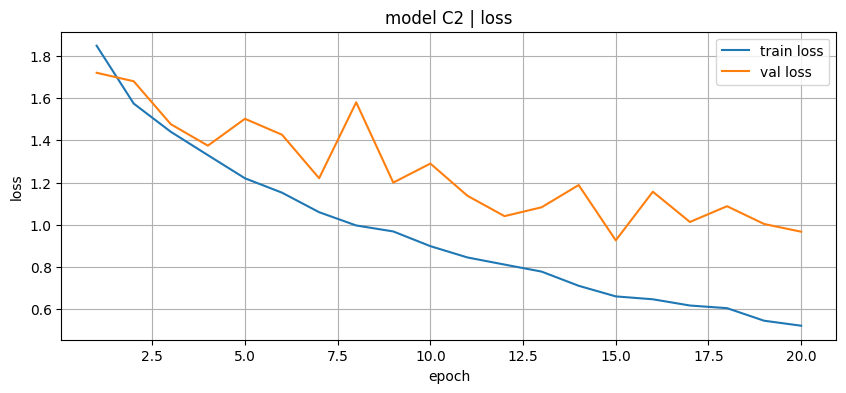

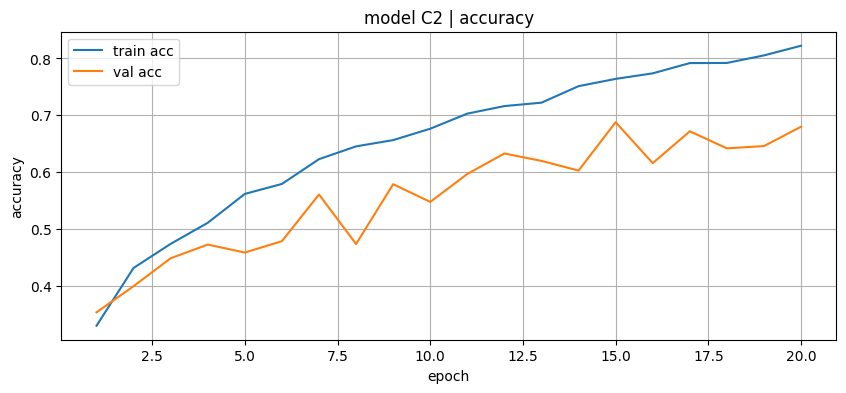

In [ ]:
criterion = nn.CrossEntropyLoss()

C2 = MyCNN().to(device)
optimizer = optim.Adam(C2.parameters(), lr=1e-3, weight_decay=0.0)

histC2 = fit(C2, train_loader2, val_loader2, optimizer, criterion, 20, early_stopping=EarlyStopping())
plot_history(histC2, "model C2")

In [ ]:
runs = pd.read_csv("./artifacts/runs.csv")

new_row = {
    "experiment_id": "C2",
    "task": "classification",
    "dataset": "STL10",
    "seed": 42,
    "model_summary": {"features": {"Conv2d": (3, 32, 64, 128, 256),
                                   "activation": "ReLU",
                                   "MaxPool2d": 2},
                    "classifier": {"hiden size": (512, 64), 
                                   "activation": "ReLU", 
                                   "dropout": 0.2, 
                                   "batchnorm": True}
                      },
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": 19,
    "best_val_accuracy": max(histC2["val_acc"]),
    "test_accuracy": evaluate(C2, test_loader2, nn.CrossEntropyLoss())[1],
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "note": None
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
modelRes18 = build_resnet18(num_classes=10).to(device)
print(modelRes18)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Epoch 01/10 | train loss 1.4060, acc 0.539 | val loss 0.8104, acc 0.762
Epoch 02/10 | train loss 0.7959, acc 0.757 | val loss 0.6759, acc 0.796
Epoch 03/10 | train loss 0.6730, acc 0.792 | val loss 0.6010, acc 0.817
Epoch 04/10 | train loss 0.6479, acc 0.785 | val loss 0.5765, acc 0.820
Epoch 05/10 | train loss 0.5757, acc 0.814 | val loss 0.5872, acc 0.819
Epoch 06/10 | train loss 0.5768, acc 0.810 | val loss 0.5650, acc 0.821
Epoch 07/10 | train loss 0.5378, acc 0.825 | val loss 0.5753, acc 0.812
Epoch 08/10 | train loss 0.5397, acc 0.816 | val loss 0.5321, acc 0.829
Epoch 09/10 | train loss 0.5205, acc 0.823 | val loss 0.5415, acc 0.823
Epoch 10/10 | train loss 0.4978, acc 0.833 | val loss 0.5351, acc 0.825


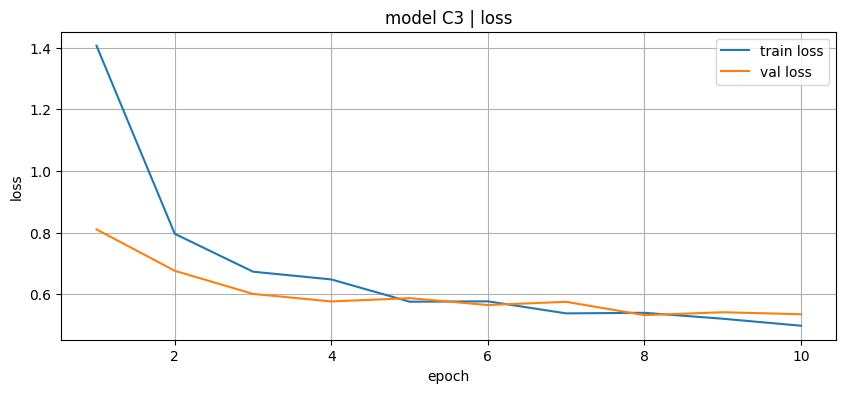

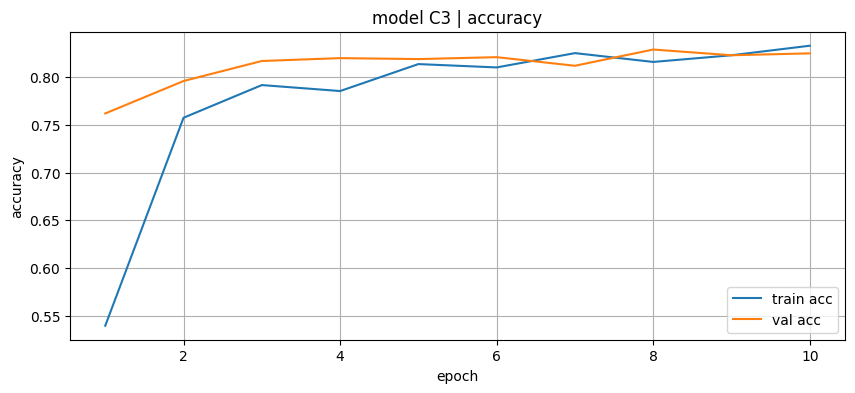

In [ ]:
criterion = nn.CrossEntropyLoss()

C3 = build_resnet18().to(device)
set_requires_grad(C3, False)
set_requires_grad(C3.fc, True)

optimizer = optim.Adam(C3.fc.parameters(), lr=1e-3)

histC3 = fit(C3, train_loader2, val_loader2, optimizer, criterion, 10, early_stopping=EarlyStopping())
plot_history(histC3, "model C3")


In [ ]:
runs = pd.read_csv("./artifacts/runs.csv")

new_row = {
    "experiment_id": "C3",
    "task": "classification",
    "dataset": "STL10",
    "seed": 42,
    "model_summary": {"features": "resnet18_weights",
                    "classifier": {"hiden size": (), 
                                   "activation": "ReLU", 
                                   "dropout": 0.0, 
                                   "batchnorm": False}
                      },
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": 10,
    "best_val_accuracy": max(histC3["val_acc"]),
    "test_accuracy": evaluate(C3, test_loader, nn.CrossEntropyLoss())[1],
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "note": None
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/10 | train loss 0.8569, acc 0.714 | val loss 0.4598, acc 0.835
Epoch 02/10 | train loss 0.3298, acc 0.892 | val loss 0.4055, acc 0.867
Epoch 03/10 | train loss 0.2327, acc 0.925 | val loss 0.3902, acc 0.866
Epoch 04/10 | train loss 0.1561, acc 0.949 | val loss 0.3553, acc 0.881
Epoch 05/10 | train loss 0.1180, acc 0.962 | val loss 0.3687, acc 0.873
Epoch 06/10 | train loss 0.0824, acc 0.974 | val loss 0.4206, acc 0.858
Epoch 07/10 | train loss 0.0688, acc 0.981 | val loss 0.4185, acc 0.870
Epoch 08/10 | train loss 0.0652, acc 0.977 | val loss 0.3975, acc 0.882
Epoch 09/10 | train loss 0.0551, acc 0.982 | val loss 0.4378, acc 0.866
Epoch 10/10 | train loss 0.0383, acc 0.989 | val loss 0.4189, acc 0.884


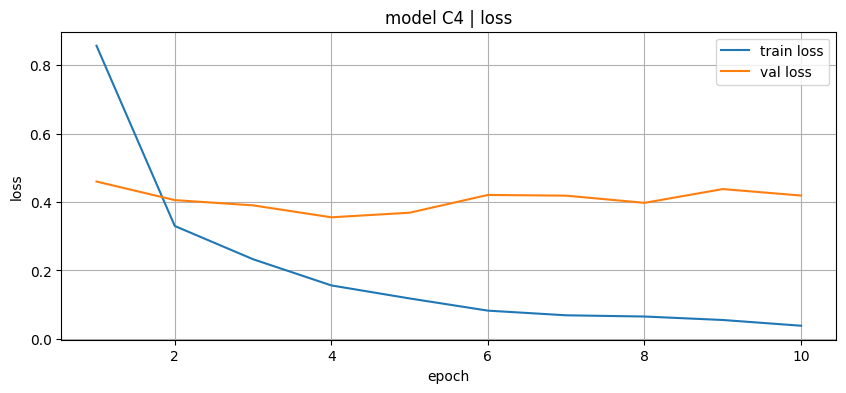

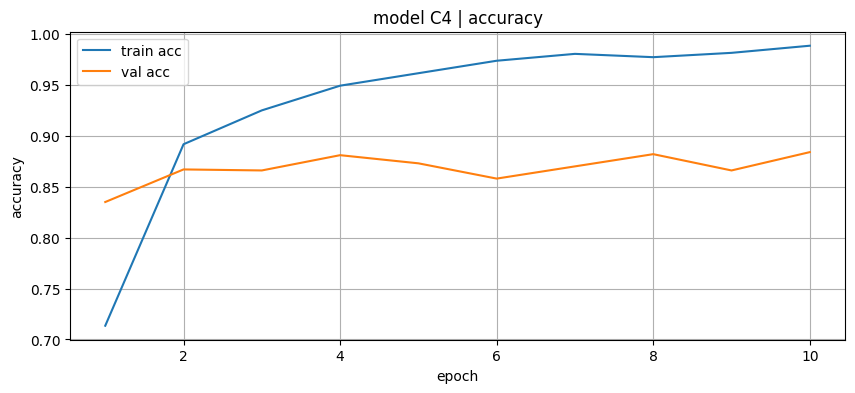

In [ ]:
criterion = nn.CrossEntropyLoss()

C4 = build_resnet18().to(device)
set_requires_grad(C4, False)
set_requires_grad(C4.layer4, True)
set_requires_grad(C4.fc, True)

params = [
    {"params": C4.layer4.parameters(), "lr": 1e-4},
    {"params": C4.fc.parameters(), "lr": 1e-3},
]

optimizer = optim.Adam(params, weight_decay=1e-4)

histC4 = fit(C4, train_loader2, val_loader2, optimizer, criterion, 10, early_stopping=EarlyStopping())
plot_history(histC4, "model C4")

In [ ]:
runs = pd.read_csv("./artifacts/runs.csv")

new_row = {
    "experiment_id": "C4",
    "task": "classification",
    "dataset": "STL10",
    "seed": 42,
    "model_summary": {"features": "fine-tune (reconfigured 4 layer)",
                    "classifier": {"hiden size": (), 
                                   "activation": "ReLU", 
                                   "dropout": 0.0, 
                                   "batchnorm": False}
                      },
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": 10,
    "best_val_accuracy": max(histC4["val_acc"]),
    "test_accuracy": evaluate(C4, test_loader2, nn.CrossEntropyLoss())[1],
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "note": None
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

d:\study\aie_std\pythonPjResh\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
torch.save(C4.state_dict(), "./artifacts/best_classifier.pt")

In [ ]:
config_best_model = {
    "dataset": "STL10",
    "seed": 42,
    "type": "ResNet18(fine-tune)",
    "input_dim": (3, 96, 96),
    "num_classes": 10,
    "activation": "ReLU",
    "dropout": 0.0,
    "batchnorm": False,
    "transforms":"Resize(110); RandomResizedCrop(96, scale=(0.7, 1.0)); RandomHorizontalFlip",
    "optimizer": "Adam",
    "lr": (1e-4, 1e-3),
    "weight_decay": 1e-4,
    "epochs": 10,
    "batch_size": 64
}

with open("./artifacts/best_classifier_config.json", "w") as f:
    json.dump(config_best_model, f, indent=4)

<Figure size 1000x400 with 0 Axes>

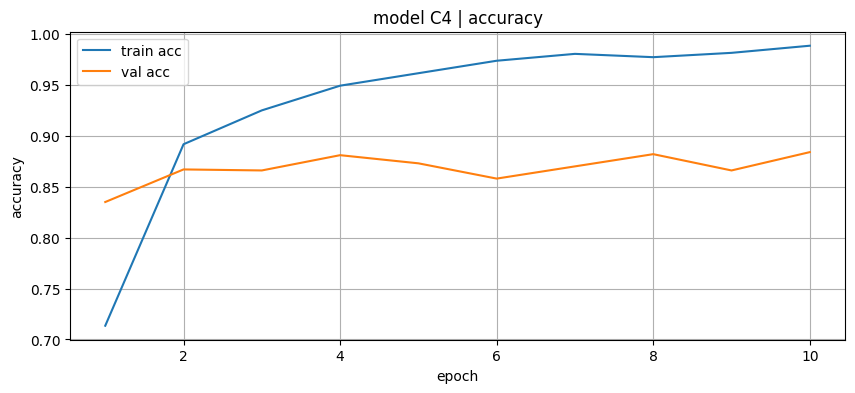

In [ ]:
epochs = list(range(1, len(histC4["train_loss"]) + 1))

plt.figure(figsize=(10, 4))

plt.figure(figsize=(10, 4))
plt.plot(epochs, histC4["train_acc"], label="train acc")
plt.plot(epochs, histC4["val_acc"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("model C4 | accuracy")
plt.grid(True)
plt.legend()
plt.savefig("./artifacts/figures/classification_curves_best.png")

<Figure size 1000x400 with 0 Axes>

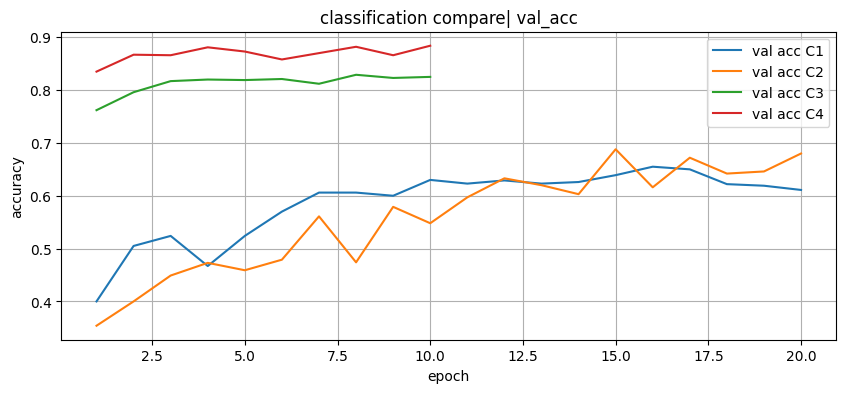

In [ ]:
epochs1 = list(range(1, len(histC1["train_loss"]) + 1))
epochs2 = list(range(1, len(histC2["train_loss"]) + 1))
epochs3 = list(range(1, len(histC3["train_loss"]) + 1))
epochs4 = list(range(1, len(histC4["train_loss"]) + 1))


plt.figure(figsize=(10, 4))

plt.figure(figsize=(10, 4))
plt.plot(epochs1, histC1["val_acc"], label="val acc C1")
plt.plot(epochs2, histC2["val_acc"], label="val acc C2")
plt.plot(epochs3, histC3["val_acc"], label="val acc C3")
plt.plot(epochs4, histC4["val_acc"], label="val acc C4")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("classification compare| val_acc")
plt.grid(True)
plt.legend()
plt.savefig("./artifacts/figures/classification_compare.png")

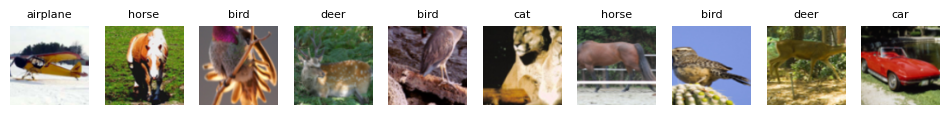

In [ ]:
x_batch, y_batch = next(iter(train_loader2))[:10]
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    img = denorm(x_batch[i]).clamp(0, 1).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(train_full.classes[y_batch[i].item()], fontsize=8)
    plt.axis("off")
plt.savefig("./artifacts/figures/augmentations_preview.png")


От сюда начинается новая шизнь. Забудьте всё чему вас учили в школе 

НАЧИНАЕМ НАШЕ ЛУДОПРИКЛЮЧЕНИЕ
ДА-ДА НЕТ-НЕТ ДА БУДЕТ СВЕТ

In [ ]:
@dataclass
class RunConfig:
    data_dir: str = "./data2"
    fast_mode: bool = True
    n_show: int = 3
    cat_only: bool = True  # мы считаем IoU только по классу "cat"

cfg = RunConfig()
cfg

RunConfig(data_dir='./data2', fast_mode=True, n_show=3, dog_only=True)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

torchvision.datasets.OxfordIIITPet(root="./data2", split="trainval", download=True, transform=transform)

Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: ./data2
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
           )

In [60]:
class SigmDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "images")
        self.mask_dir = os.path.join(root, "annotations/trimaps")

        self.imgs = sorted([f for f in os.listdir(self.img_dir) if f.lower().endswith(".jpg")])
        self.masks = sorted([f for f in os.listdir(self.mask_dir) if f.lower().endswith(".png")])

        if len(self.imgs) == 0 or len(self.imgs) != len(self.masks):
            raise RuntimeError(f"Похоже, структура PennFudanPed повреждена или не распакована полностью.({len(self.imgs)}, {len(self.masks)})")

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # instance mask -> бинарная маска "шущество"
        mask_np = np.array(mask)
        gt = (mask_np > 0).astype(np.uint8)  # [H,W], 0/1

        return img, gt  # img = PIL, gt = numpy

dataset_OP = SigmDataset("./data2/oxford-iiit-pet")
len(dataset_OP), dataset_OP[0][0].size, dataset_OP[0][1].shape

(7390, (600, 400), (400, 600))

In [61]:
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(device)
model.eval()

categories = weights.meta.get("categories", None)
if categories is None:
    raise RuntimeError("В weights.meta нет списка categories – сложно найти индекс 'cat' динамически.")

if "cat" not in categories:
    raise RuntimeError("В categories нет класса 'cat'. Проверьте, какие веса вы загрузили.")

CAT_IDX = categories.index("cat")
DOG_IDX = categories.index("dog")

print("num_classes:", len(categories))
print("CAT_IDX:", CAT_IDX)
print("DOG_IDX:", DOG_IDX)


# Трансформации, соответствующие обучению этих весов
preprocess = weights.transforms()
preprocess

num_classes: 21
CAT_IDX: 8
DOG_IDX: 12


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [81]:
@torch.no_grad()
def predict_cat_mask(img_pil: Image.Image) -> torch.Tensor:
    '''
    Возвращает бинарную маску (H,W) для класса CAT_IDX в пространстве модели.
    '''
    x = preprocess(img_pil).unsqueeze(0).to(device)  # [1,3,H,W]
    out = model(x)["out"][0]  # [C,H,W]
    pred = out.argmax(0)      # [H,W]
    cat = (pred == int(CAT_IDX)).to(torch.uint8)
    return cat.cpu(), x.shape[-2:]  # (mask, (H,W))

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def eval_subset(indices: List[int]) -> Dict[str, float]:
    ious = []
    for idx in indices:
        img_pil, gt_np = dataset_OP[idx]
        pred_mask, (h, w) = predict_cat_mask(img_pil)

        # resize GT to model space (nearest!)
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

if cfg.fast_mode:
    eval_indices = list(range(min(50, len(dataset_OP))))
else:
    eval_indices = list(range(len(dataset_OP)))

metricsv1 = eval_subset(eval_indices)
metricsv1

{'n': 50.0,
 'mean_IoU': 0.3041361094517799,
 'median_IoU': 0.2751799056514954,
 'min_IoU': 0.07913954635108462,
 'max_IoU': 0.5907045548369321}

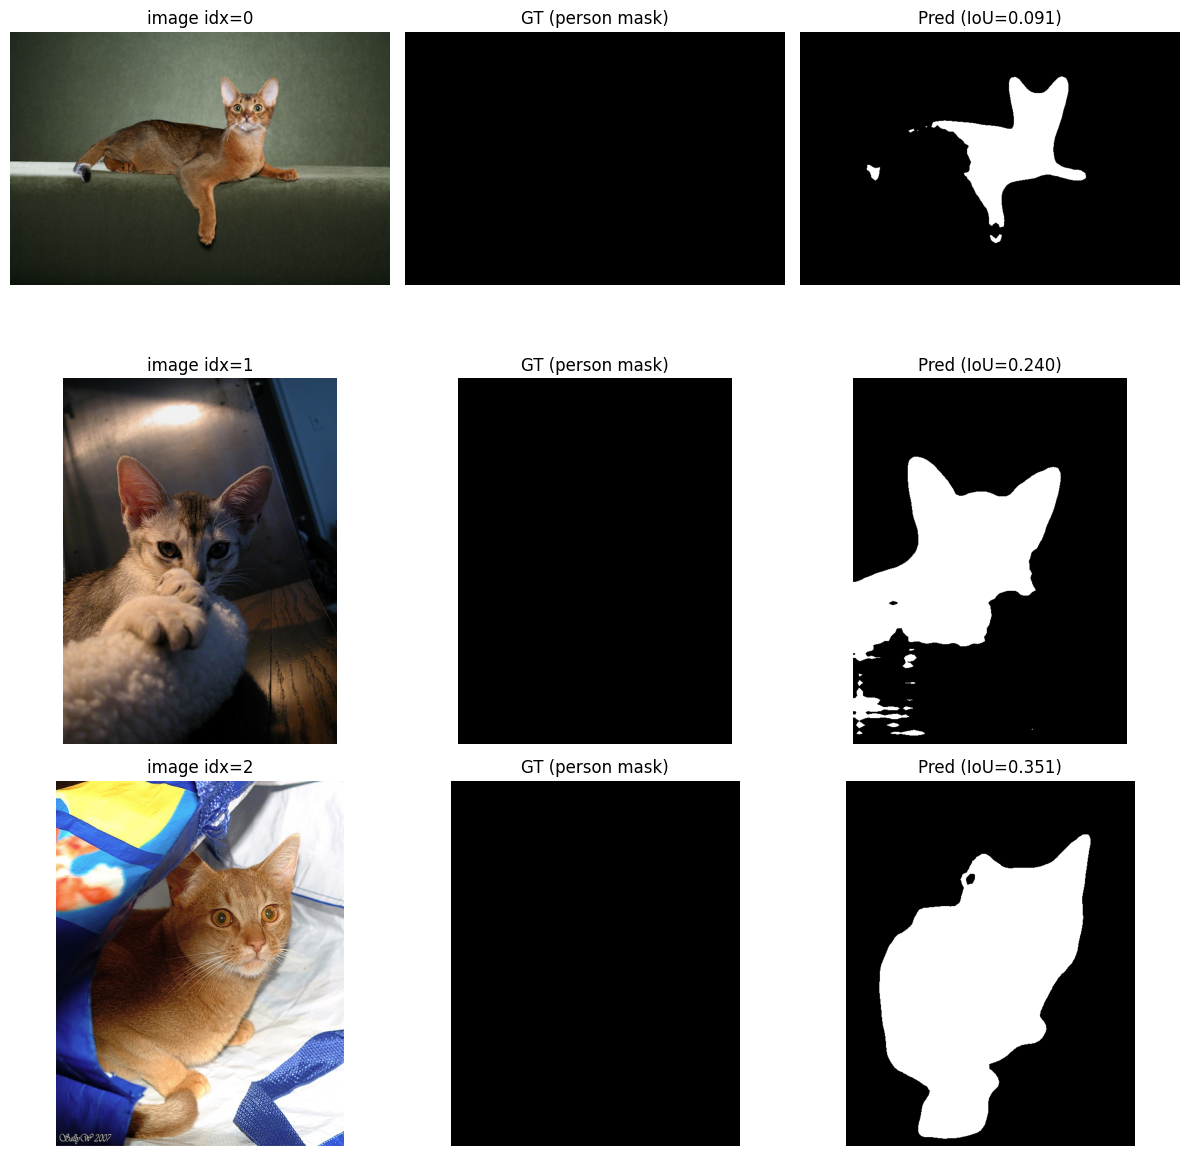

In [66]:
n = min(cfg.n_show, len(dataset_OP))
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_pil, gt_np = dataset_OP[row]
    pred_mask, (h, w) = predict_cat_mask(img_pil)

    # GT resize to model space
    gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou = iou_binary(pred_mask, gt_mask)

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"image idx={row}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    axes[row, 1].set_title("GT (person mask)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_mask.numpy(), cmap="gray")
    axes[row, 2].set_title(f"Pred (IoU={iou:.3f})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("./artifacts/figures/segmentation_examples.png")
plt.show()

In [67]:
runs = pd.read_csv("./artifacts/runs.csv")

new_row = {
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": 42,
    "model_summary": {"architecture": "deeplabv3_resnet50",
                    "weights": "DeepLabV3_ResNet50_Weights"
                      },
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_accuracy": None,
    "test_accuracy": None,
    "precision": None,
    "recall": None,
    "mean_iou": 0.3041361094517799,
    "note": 50
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_17024\3401838744.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs.loc[len(runs)] = new_row


In [79]:
@torch.no_grad()
def predict_cat_mask_prod(img_pil: Image.Image) -> torch.Tensor:
    '''
    Возвращает бинарную маску (H,W) для класса CAT_IDX в пространстве модели.
    '''
    x = preprocess(img_pil).unsqueeze(0).to(device)  # [1,3,H,W]
    out = model(x)["out"][0]  # [C,H,W]
    probs = torch.softmax(out, dim=0)
    cat = (probs[CAT_IDX] > 0.3).to(torch.uint8)
    return cat.cpu(), x.shape[-2:]  # (mask, (H,W))


def eval_subset_prod(indices: List[int]) -> Dict[str, float]:
    ious = []
    for idx in indices:
        img_pil, gt_np = dataset_OP[idx]
        pred_mask, (h, w) = predict_cat_mask_prod(img_pil)

        # resize GT to model space (nearest!)
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

if cfg.fast_mode:
    eval_indices = list(range(min(50, len(dataset_OP))))
else:
    eval_indices = list(range(len(dataset_OP)))

metricsv2 = eval_subset_prod(eval_indices)
metricsv2

{'n': 50.0,
 'mean_IoU': 0.3224936058969037,
 'median_IoU': 0.287340574548907,
 'min_IoU': 0.0822707100591714,
 'max_IoU': 0.6370781527531062}

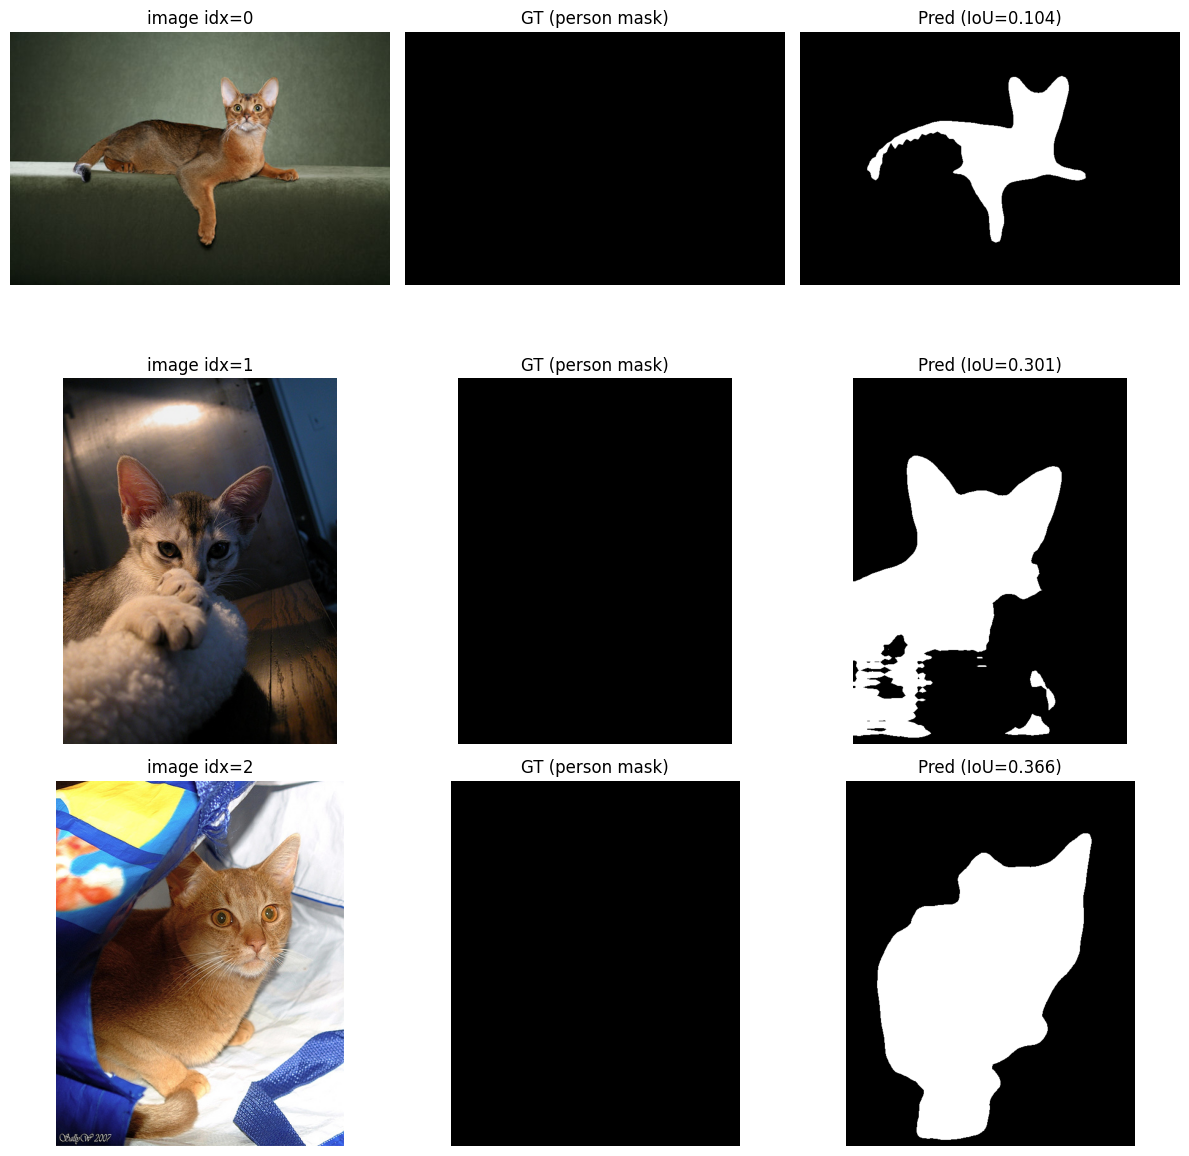

In [74]:
n = min(cfg.n_show, len(dataset_OP))
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_pil, gt_np = dataset_OP[row]
    pred_mask, (h, w) = predict_cat_mask_prod(img_pil)

    # GT resize to model space
    gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou = iou_binary(pred_mask, gt_mask)

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"image idx={row}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    axes[row, 1].set_title("GT (person mask)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_mask.numpy(), cmap="gray")
    axes[row, 2].set_title(f"Pred (IoU={iou:.3f})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

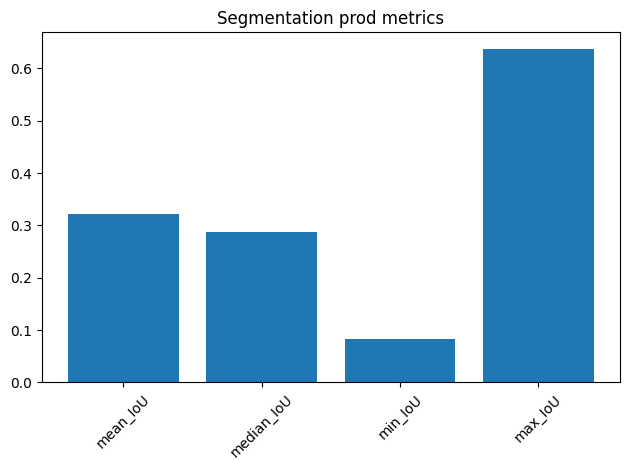

In [83]:
names = list(metricsv1.keys())[1:]
valuesv1 = list(metricsv1.values())[1:]
valuesv2 = list(metricsv2.values())[1:]


plt.figure()
plt.bar(names, valuesv2)
plt.title("Segmentation prod metrics")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("./artifacts/figures/segmentation_metrics.png")

In [84]:
runs = pd.read_csv("./artifacts/runs.csv")

new_row = {
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": 42,
    "model_summary": {"architecture": "deeplabv3_resnet50",
                    "weights": "DeepLabV3_ResNet50_Weights",
                    "prod": "probs > 0.3"},
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_accuracy": None,
    "test_accuracy": None,
    "precision": None,
    "recall": None,
    "mean_iou": 0.3224936058969037,
    "note": 50
}

runs.loc[len(runs)] = new_row

runs.to_csv("./artifacts/runs.csv", index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_17024\275642178.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs.loc[len(runs)] = new_row
